In [87]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
#pd.set_option('display.max_columns', 1500)

In [88]:
df = pd.read_csv('../data/raw/Diffusion.csv')

In [89]:
diffusion_tool = df[df["Tool ID"] == 0]

## Tool Parameters
Input 1 range: 1000-1400, aggression: 8
Input 2 range: 50-80, aggression: 3
Output range: 0.5-2

In [90]:
diffusion_tool.head(10)

,Tool Group,Tool ID,LotID,Time In,Time Out,Input 1,Input 2,Output,Failed
0,Diffusion,0,2,594,1028,1152.937293,48.586070,0.509620,False
3,Diffusion,0,3,1282,1839,1164.084168,52.233560,0.572394,False
6,Diffusion,0,16,3030,3531,1171.462747,52.410145,0.578883,False
7,Diffusion,0,18,3675,4035,1179.431171,52.369064,0.581696,False
10,Diffusion,0,26,4219,4758,1236.159615,54.692827,0.666913,False
12,Diffusion,0,22,4758,5137,1243.350958,55.955135,0.706180,False
15,Diffusion,0,30,5137,5611,1249.856796,55.925077,0.710652,False
18,Diffusion,0,31,5611,6235,1258.401888,56.364865,0.730396,False
22,Diffusion,0,43,6235,6762,1269.421110,56.305940,0.738081,False
26,Diffusion,0,38,6762,7308,1330.922725,57.740610,0.843482,False


## Holistic View of Data

In [91]:
diffusion_tool.describe()

,Tool ID,LotID,Time In,Time Out,Input 1,Input 2,Output
count,10638.0,10638.000000,1.063800e+04,1.063800e+04,10638.000000,10638.000000,10638.000000
mean,0.0,25977.471799,2.594714e+06,2.595195e+06,1368.235831,59.767719,1.065624
std,0.0,15009.277151,1.495289e+06,1.495289e+06,229.536532,6.564014,0.492883
min,0.0,2.000000,5.940000e+02,1.028000e+03,998.721108,45.109674,0.430338
25%,0.0,12993.000000,1.301354e+06,1.301771e+06,1178.575672,54.186859,0.616237
50%,0.0,26066.000000,2.595050e+06,2.595520e+06,1357.694346,59.395464,0.936276
75%,0.0,38782.250000,3.888956e+06,3.889371e+06,1529.309394,64.743608,1.446032
max,0.0,51995.000000,5.183030e+06,5.183532e+06,2574.244071,82.375120,2.720643


All data points seem to be within the ranges of the tool, no values go past the minimum and maximum range values.

## Univariate Distributions

Looking at Inputs first, ensuring monotonic drift:

Text(0, 0.5, 'Runs')

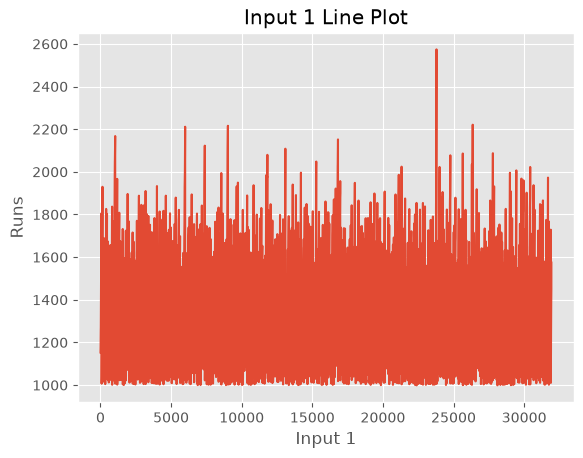

In [92]:
line = diffusion_tool['Input 1'].plot(kind='line', title="Input 1 Line Plot")
line.set_xlabel('Input 1')
line.set_ylabel('Runs')

Text(0, 0.5, 'Runs')

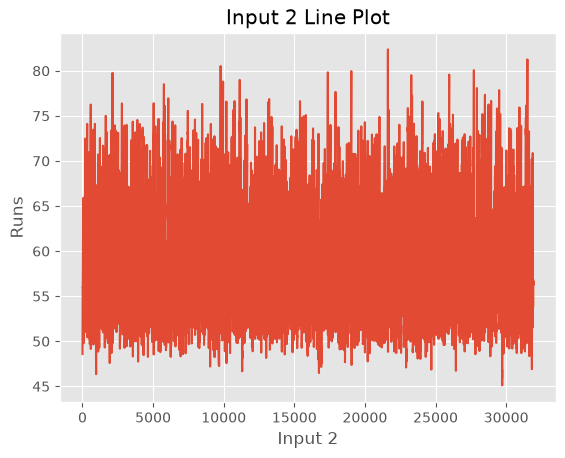

In [93]:
line = diffusion_tool['Input 2'].plot(kind='line', title="Input 2 Line Plot")
line.set_xlabel('Input 2')
line.set_ylabel('Runs')

Both are showing what would be expected from degradation-driven inputs. Both show monotonic drift, although the noise in Input 2 seems to have a greater relative effect since Input 2 is much smaller in terms of magnitude.

Now an analysis of output

Text(0, 0.5, 'Runs')

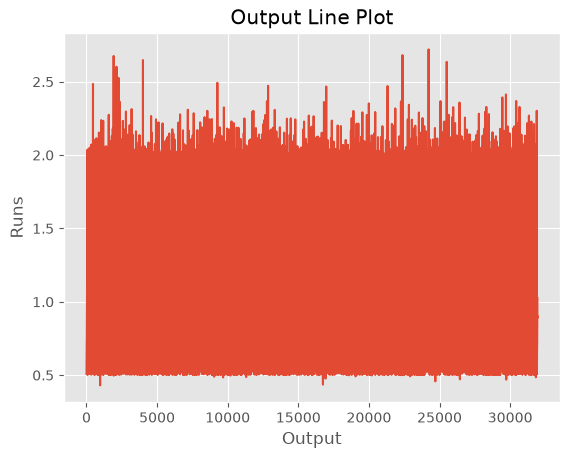

In [94]:
line = diffusion_tool['Output'].plot(kind='line', title="Output Line Plot")
line.set_xlabel('Output')
line.set_ylabel('Runs')

All peaks have one data point before the output resets, and the output climbs as expected.

Visualising inputs and outputs together:

<Axes: >

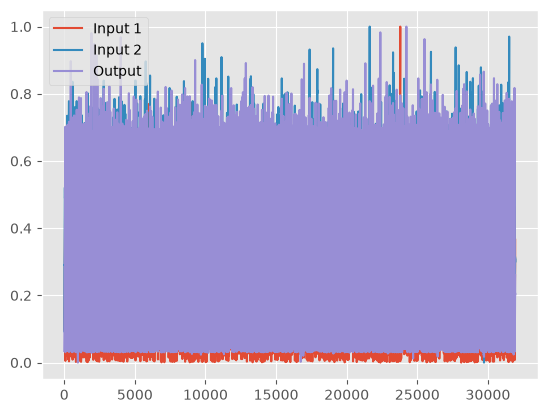

In [95]:
df_norm = (diffusion_tool[['Input 1', 'Input 2', 'Output']] - diffusion_tool[['Input 1', 'Input 2', 'Output']].min()) / \
          (diffusion_tool[['Input 1', 'Input 2', 'Output']].max() - diffusion_tool[['Input 1', 'Input 2', 'Output']].min())
df_norm.plot(kind='line')

Peaks and dips meet.

## Multivariate Analysis

Looking into variable relationships

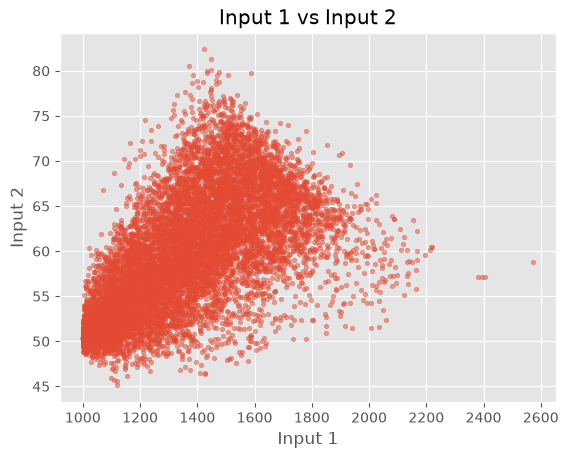

In [96]:
plt.scatter(diffusion_tool['Input 1'], diffusion_tool['Input 2'], alpha=0.5, s=10)
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.title('Input 1 vs Input 2')
plt.show()

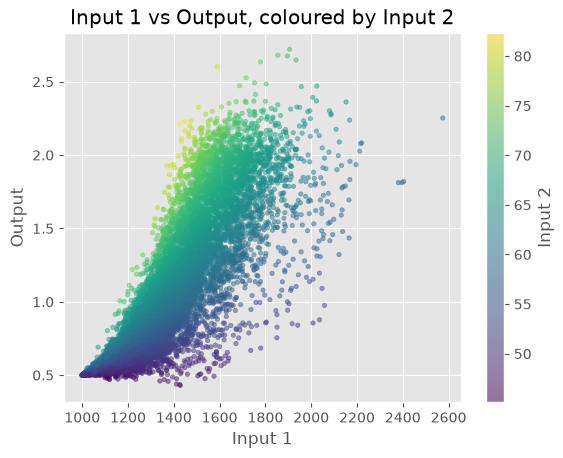

In [97]:
scatter = plt.scatter(diffusion_tool['Input 1'], diffusion_tool['Output'], c=diffusion_tool['Input 2'], alpha=0.5, s=10, cmap='viridis')
plt.xlabel('Input 1')
plt.ylabel('Output')
plt.colorbar(scatter, label='Input 2')
plt.title('Input 1 vs Output, coloured by Input 2')
plt.show()

Input 1 vs Input 2 shows a loose diagonal trend upwards. Both are independently randomised, but they're coupled through time since both reset together regardless of how they've changed over a cycle.

Input 1 vs Output (coloured by Input 2) shows a clear vertical band, where lower valuers correspond to a lower output and vice versa. Input 2 modulates on top of Input 1.

Output's dependence on Input 1 is not uniform across a cycle. Variance explained by Input 1 alone shrinks as the cycle progresses, consistent with the cxy interaction term growing with x. This suggests Input 2 (and their interaction) becomes increasingly important as a feature later in a cycle, which matters directly for RUL prediction near end-of-life. Furthermore, a simple linear regression model on raw Input 1 alone will likely underfit the curvature observed in the graph above, and so another model will likely need to be used.

This confirms that the formula used, output = kf(i1,i2) + c ,where f = i1 + i2^2 + 0.5(i1*i2), is outputting data as expected.

In [98]:
diffusion_tool[['Input 1', 'Input 2', 'Output']].corr()

,Input 1,Input 2,Output
Input 1,1.000000,0.594166,0.847569
Input 2,0.594166,1.000000,0.878788
Output,0.847569,0.878788,1.000000


In [99]:
diffusion_tool['Input 2'].pow(2).corr(df['Output'])

np.float64(0.8792852309914423)

As expected, Input 1 has a strong linear relationship with Output. Within the formula, Input 1 has a direct linear term in the formula used. Surprisingly, Input 2 has the strongest pairwise correlation,  potentially explained by Input 2 having a much narrower range than Input 1, so its quadratic contribution does not have enough room to show its non-linearity. A look into the pearson correlation between Input 2 squared and output shows near enough the same value, confirming that the range is too narrow to see meaningful non-linear trends.

In [100]:
diffusion_tool["Shifted"] = diffusion_tool["Failed"].shift(periods=1, fill_value= False)
diffusion_tool["Cycle Group"] = diffusion_tool["Shifted"].cumsum()
diffusion_tool["Forward"] = diffusion_tool.groupby(["Cycle Group"]).cumcount()
diffusion_tool["Cycle Size"] = diffusion_tool.groupby("Cycle Group")["Failed"].transform("size")
diffusion_tool["RUL"] = diffusion_tool["Cycle Size"] - diffusion_tool["Forward"] - 1
diffusion_tool.drop(columns=['Shifted','Cycle Size','Forward'])


,Tool Group,Tool ID,LotID,Time In,Time Out,Input 1,Input 2,Output,Failed,Cycle Group,RUL
0,Diffusion,0,2,594,1028,1152.937293,48.586070,0.509620,False,0,25
3,Diffusion,0,3,1282,1839,1164.084168,52.233560,0.572394,False,0,24
6,Diffusion,0,16,3030,3531,1171.462747,52.410145,0.578883,False,0,23
7,Diffusion,0,18,3675,4035,1179.431171,52.369064,0.581696,False,0,22
10,Diffusion,0,26,4219,4758,1236.159615,54.692827,0.666913,False,0,21
...,...,...,...,...,...,...,...,...,...,...,...
31917,Diffusion,0,51972,5181072,5181610,1383.664174,55.561964,0.804431,False,474,4
31921,Diffusion,0,51970,5181610,5182176,1418.186022,55.840956,0.843892,False,474,3
31924,Diffusion,0,51978,5182176,5182598,1446.078530,56.644263,0.905238,False,474,2
31927,Diffusion,0,51987,5182598,5183030,1451.508979,56.232784,0.889884,False,474,1


<Axes: xlabel='RUL', ylabel='Input 1'>

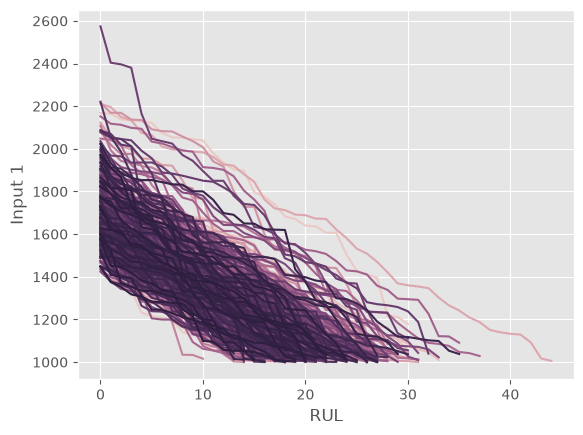

In [101]:
sns.lineplot(data=diffusion_tool, x="RUL", y="Input 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Input 2'>

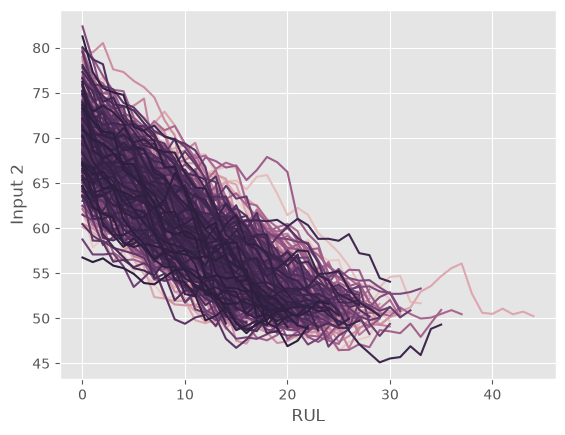

In [102]:
sns.lineplot(data=diffusion_tool, x="RUL", y="Input 2", hue="Cycle Group", legend = False)

Comparing the inputs the RUL, we observe that each cycle follows a similar trend, however there is no single value to single value mapping. At 60 for input 2 for example, it maps to multiple RUL values, suggesting that raw sensor values are not good indicators of RUL, and so will not be used as features to train the model. 

In [103]:
diffusion_tool["Rolling Mean 1"] = diffusion_tool.groupby("Cycle Group")["Input 1"].rolling(5).mean().reset_index(level=0,drop=True)
diffusion_tool["Rolling Mean 2"] = diffusion_tool.groupby("Cycle Group")["Input 2"].rolling(5).mean().reset_index(level=0,drop=True)


<Axes: xlabel='RUL', ylabel='Rolling Mean 1'>

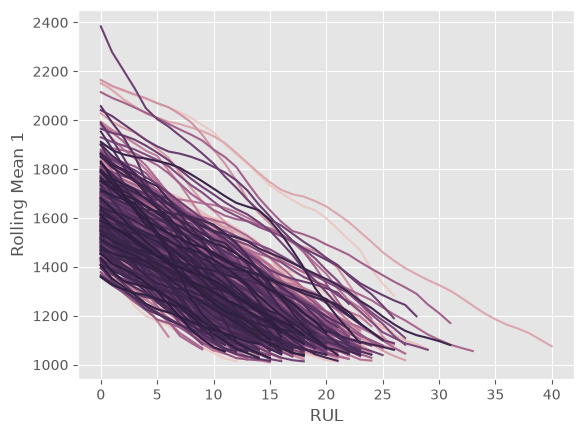

In [104]:
sns.lineplot(data=diffusion_tool, x="RUL", y="Rolling Mean 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Rolling Mean 2'>

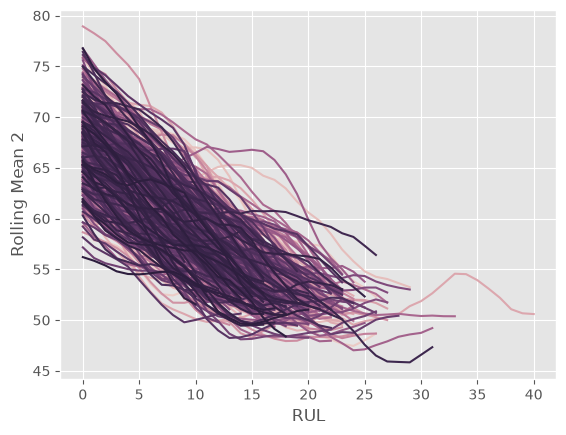

In [105]:
sns.lineplot(data=diffusion_tool, x="RUL", y="Rolling Mean 2", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Rolling Std 1'>

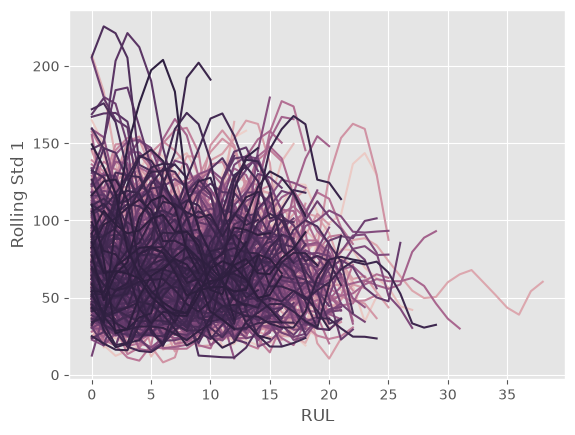

In [106]:
diffusion_tool["Rolling Std 1"] = diffusion_tool.groupby("Cycle Group")["Input 1"].rolling(7).std().reset_index(level=0,drop=True)
diffusion_tool["Rolling Std 2"] = diffusion_tool.groupby("Cycle Group")["Input 2"].rolling(7).std().reset_index(level=0,drop=True)
sns.lineplot(data=diffusion_tool, x="RUL", y="Rolling Std 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Rolling Std 2'>

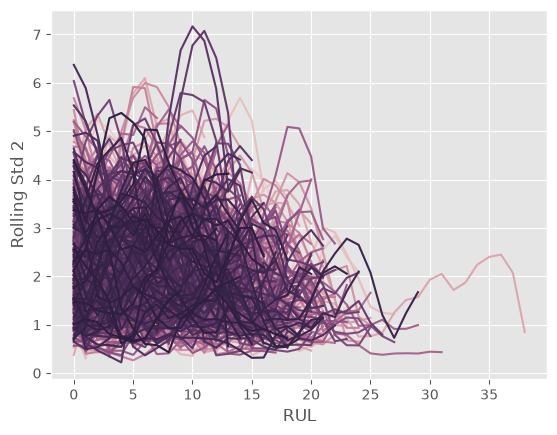

In [107]:
sns.lineplot(data=diffusion_tool, x="RUL", y="Rolling Std 2", hue="Cycle Group", legend = False)

In [108]:
n = 5
diffusion_tool["Shift1"] = diffusion_tool.groupby("Cycle Group")["Rolling Mean 1"].shift(n)
diffusion_tool["RoC1"] = diffusion_tool["Rolling Mean 1"] - diffusion_tool["Shift1"]

diffusion_tool["Shift2"] = diffusion_tool.groupby("Cycle Group")["Rolling Mean 2"].shift(n)
diffusion_tool["RoC2"] = diffusion_tool["Rolling Mean 2"] - diffusion_tool["Shift2"]

<Axes: xlabel='RUL', ylabel='RoC1'>

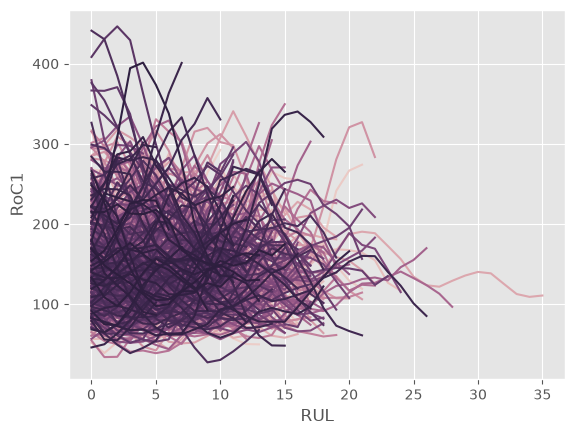

In [109]:
sns.lineplot(data=diffusion_tool, x="RUL", y="RoC1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='RoC2'>

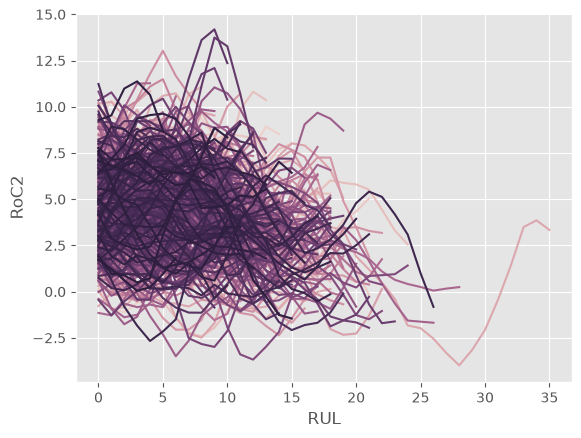

In [110]:
sns.lineplot(data=diffusion_tool, x="RUL", y="RoC2", hue="Cycle Group", legend = False)